In [2]:
import pandas as pd
import dask.dataframe as dd

In [3]:
tf = pd.read_csv("Trips_Full Data.csv")

In [4]:
td = pd.read_csv("Trips_by_Distance.csv")

In [5]:
td.columns = (td.columns.str.strip().str.lower().str.replace(" ","_"))
td = td.fillna(td.mean(numeric_only=True)) # fills missing numeric values with its mean 

In [6]:
# handles missing categorical values
td["state_postal_code"] = td["state_postal_code"].fillna("Unknown")
td["county_name"] = td["county_name"].fillna("Unknown")

In [7]:
tf.columns = (tf.columns.str.strip().str.lower().str.replace(" ","_"))  

In [8]:
td.dtypes

level                              object
date                               object
state_fips                        float64
state_postal_code                  object
county_fips                       float64
county_name                        object
population_staying_at_home        float64
population_not_staying_at_home    float64
number_of_trips                   float64
number_of_trips_<1                float64
number_of_trips_1-3               float64
number_of_trips_3-5               float64
number_of_trips_5-10              float64
number_of_trips_10-25             float64
number_of_trips_25-50             float64
number_of_trips_50-100            float64
number_of_trips_100-250           float64
number_of_trips_250-500           float64
number_of_trips_>=500             float64
row_id                             object
week                                int64
month                               int64
dtype: object

In [9]:
td["date"] = pd.to_datetime(td["date"])

In [10]:
tf["date"] = pd.to_datetime(tf["date"])

In [35]:
# filters national level data
national_only = td[td['level'] == "National"]

# classifies into 4 sets based on trip thresholds
set1 = national_only[national_only['number_of_trips_10-25'] > 10000000]
set2 = national_only[national_only['number_of_trips_50-100'] > 10000000]
set3 = national_only[(national_only['number_of_trips_10-25'] > 10000000) & 
                      (national_only['number_of_trips_50-100'] > 10000000)]
set4 = national_only[(national_only['number_of_trips_10-25'] > 10000000) & 
                      (national_only['number_of_trips_50-100'] < 10000000)]

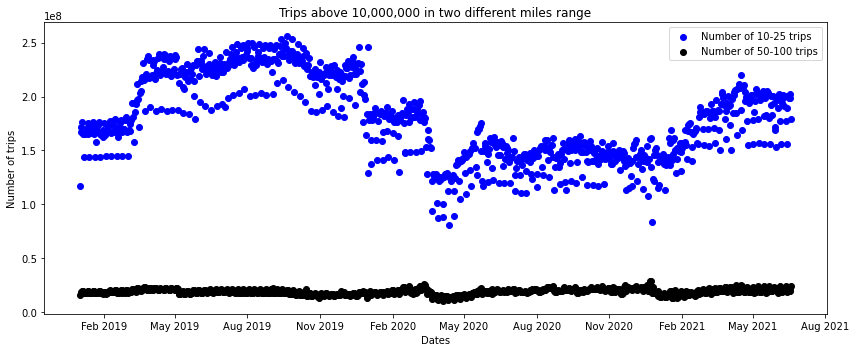

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

national_data = td[td["level"] == "National"]

set1 = national_data[national_data["number_of_trips_10-25"] > 10000000].copy()
set2 = national_data[national_data["number_of_trips_50-100"] > 10000000].copy()

set1["date"] = pd.to_datetime(set1["date"])
set2["date"] = pd.to_datetime(set2["date"])

plt.figure(figsize=(12,5))

plt.scatter(set1["date"], set1["number_of_trips_10-25"], color="blue", label="Number of 10-25 trips")
plt.scatter(set2["date"], set2["number_of_trips_50-100"], color="black", label="Number of 50-100 trips")

plt.xlabel("Dates")
plt.ylabel("Number of trips")
plt.title("Trips above 10,000,000 in two different miles range")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()